# Lecture 8: Likelihood Modeling, Bootstrap, and Jackknife Uncertainty

**Unit 2, September 22, 2026**

Lecture 6 introduced nonlinear fitting with `curve_fit`, `least_squares`, and minimizers. Lecture 7 asked whether a fitted model was statistically compatible with data using $\chi^2$, $\Delta\chi^2$, and hypothesis tests.

Today we move from Gaussian least-squares models to **Poisson likelihood models** for event counts. The example is a small, event-wise CMS Open Data dimuon sample. The physics goal is modest: model the mass intensity $I(m;\theta)$ near the $J/\psi\to\mu^+\mu^-$ peak, compare a signal-plus-background model with a background-only model, and estimate uncertainties with covariance, bootstrap, and jackknife methods.

This is a teaching analysis, not a publication-quality CMS result. We will inspect the dimuon $p_T$ distribution, but the fitted likelihood model will use invariant mass only. This keeps the likelihood example focused on a defensible model rather than forcing a visibly inadequate exponential description of $p_T$.


## Learning goals

By the end of this lecture you should be able to:

- explain what an event intensity $I(m;\theta)$ means, with $\theta$ as the vector of model parameters to be inferred,
- write an extended Poisson log-likelihood for event-wise mass data,
- fit a mass-only signal-plus-background intensity model with `scipy.optimize.minimize`,
- compare nested models using a likelihood-ratio test,
- estimate parameter uncertainties with profile likelihood, bootstrap resampling, and jackknife diagnostics,
- describe when bootstrap or jackknife methods reveal information not obvious from a covariance matrix.


# Part 1: Public CMS dimuon data

We use a reduced CSV derived from the CMS Run2010B dimuon open-data sample. The original public record is:

> Thomas McCauley, **Dimuon event information derived from the Run2010B public Mu dataset**, CERN Open Data Portal (2014), DOI: [10.7483/OPENDATA.CMS.CB8H.MFFA](https://doi.org/10.7483/OPENDATA.CMS.CB8H.MFFA).

The repository CSV used here is `data/cms_dimuon_jpsi_3000.csv`. It contains 3000 opposite-sign dimuon events selected from the invariant-mass region

$$
2.6 < m_{\mu\mu} < 3.6\ \mathrm{GeV},
$$

with a dimuon transverse momentum column constructed from the two muon momenta. The original source contains many more events; this reduced version is intentionally small enough to keep in the GitHub repository and fast enough for in-class fitting.

The fitted event coordinate is the dimuon invariant mass $m$.

The dimuon transverse momentum $p_T$ is still useful as a diagnostic distribution to inspect, but it is not included in the likelihood model below. A first attempt at a simple exponential $p_T$ model does not describe the data well, so we avoid building that wrong assumption into the fit.


In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from scipy.optimize import minimize
from scipy.special import erf
from scipy.stats import chi2

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

rng = np.random.default_rng(20260922)
print(f"NumPy {np.__version__} | pandas {pd.__version__}")

NumPy 2.5.2 | pandas 3.0.5


In [2]:
DATA_PATH_CANDIDATES = [
    Path("../data/cms_dimuon_jpsi_3000.csv"),
    Path("data/cms_dimuon_jpsi_3000.csv"),
]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), DATA_PATH_CANDIDATES[0])
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find the reduced CMS dimuon CSV. Tried: {DATA_PATH_CANDIDATES}")

cms_data = pd.read_csv(DATA_PATH)
analysis_data = cms_data.copy()
analysis_data.head()

,Run,Event,dimuon_mass_GeV,dimuon_pt_GeV,leading_muon_pt_GeV,subleading_muon_pt_GeV,Q1,Q2,Type1,Type2,opposite_sign,both_global
0,146428,16748390,2.61363,6.645782,6.01508,1.072930,1,-1,G,T,True,False
1,146430,4871608,3.01719,12.358714,11.98250,0.715687,1,-1,G,T,True,False
2,146430,5571993,3.25675,9.647192,8.44892,1.691420,-1,1,G,T,True,False
3,146430,6127418,3.59661,12.836562,12.45830,0.865104,1,-1,G,T,True,False
4,146430,6371947,3.55104,10.580960,9.03751,2.105030,1,-1,G,T,True,False


### Discussion question 1

In Lecture 7, a model predicted a value $y_i$ with uncertainty $\sigma_i$ at each measured point. Here, each row is an **event**. What should a model predict now: a value for each event, a probability density, or an expected number of events?

### In-class coding activity 1: inspect the event-wise data, 12 minutes

Complete the quick inspection below. The goal is to identify the mass range that enters the likelihood and the $p_T$ range that we inspect only as a diagnostic.


In [3]:
# TODO: Choose the mass column used in the likelihood and the pT column used for diagnostics.
mass_column = ...  # TODO: "dimuon_mass_GeV"
pt_column = ...    # TODO: "dimuon_pt_GeV"

# TODO: Compute the number of events and the mass/pT ranges.
number_of_events = ...
mass_range_from_data = (..., ...)  # TODO: min and max mass.
pt_range_from_data = (..., ...)    # TODO: min and max dimuon pT.

pd.DataFrame([
    {
        "number_of_events": number_of_events,
        "mass_min_GeV": mass_range_from_data[0],
        "mass_max_GeV": mass_range_from_data[1],
        "pt_min_GeV": pt_range_from_data[0],
        "pt_max_GeV": pt_range_from_data[1],
    }
])


,number_of_events,mass_min_GeV,mass_max_GeV,pt_min_GeV,pt_max_GeV
0,Ellipsis,Ellipsis,Ellipsis,Ellipsis,Ellipsis


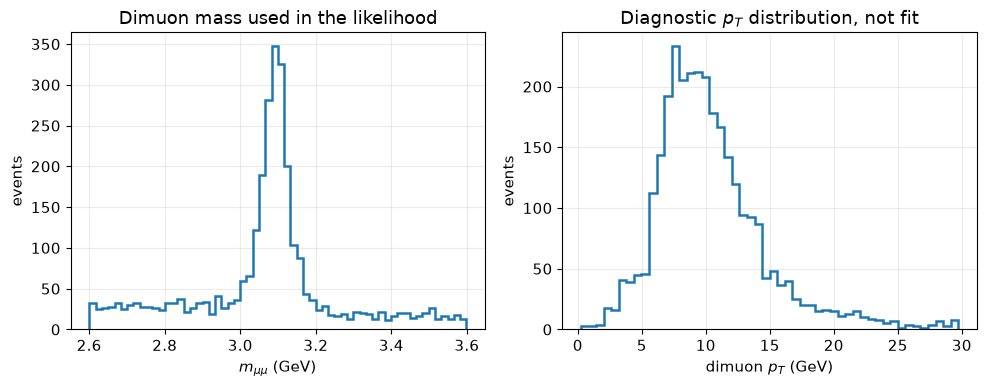

In [4]:
MASS_RANGE = (2.6, 3.6)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(analysis_data["dimuon_mass_GeV"], bins=60, histtype="step", lw=1.8)
axes[0].set_xlabel(r"$m_{\mu\mu}$ (GeV)")
axes[0].set_ylabel("events")
axes[0].set_title("Dimuon mass used in the likelihood")

axes[1].hist(analysis_data["dimuon_pt_GeV"], bins=50, histtype="step", lw=1.8)
axes[1].set_xlabel(r"dimuon $p_T$ (GeV)")
axes[1].set_ylabel("events")
axes[1].set_title(r"Diagnostic $p_T$ distribution, not fit")
fig.tight_layout()


# Part 2: From Gaussian $\chi^2$ to Poisson likelihoods

Lecture 7 used a Gaussian measurement model for repeated measurements of a quantity $y_i$:

$$
y_i \sim \mathcal{N}\left(f(x_i;\theta),\sigma_i^2\right).
$$

That assumption leads to

$$
-2\ln L(\theta)=\chi^2(\theta)+\mathrm{constant}.
$$

Today the data are different. Each row in the CMS dimuon table is an **event** with invariant mass $m$.

The symbol $\theta$ denotes the **vector of model parameters to be inferred from the data**. In this lecture, $\theta$ will include quantities such as signal yield, background yield, peak position, mass width, and background-shape parameters.

Instead of predicting a measured value $y_i$ at a fixed location, the model predicts an **event intensity**

$$
I(m;\theta),
$$

with units of expected events per GeV. Therefore

$$
N_\mathrm{expected}(\theta)=\int_{m_\mathrm{min}}^{m_\mathrm{max}} I(m;\theta)\,dm
$$

is the expected total number of events in the selected mass region.

There are three related likelihoods worth distinguishing.

**1. Gaussian least-squares likelihood.** Use this when the measured quantities are approximately Gaussian distributed around model predictions with known standard uncertainties:

$$
-2\ln L = \sum_i \left[\frac{y_i-f(x_i;\theta)}{\sigma_i}\right]^2 + \mathrm{constant}.
$$

**2. Binned Poisson likelihood.** If the data are counts $n_b$ in bins and the model predicts expected bin counts $\nu_b(\theta)$, use

$$
\ln L_\mathrm{binned}=\sum_b \left[n_b\ln\nu_b(\theta)-\nu_b(\theta)-\ln(n_b!)\right].
$$

This is often the right model for histograms, especially when counts are small enough that Gaussian approximations to bin errors are questionable.

**3. Extended unbinned Poisson likelihood.** A likelihood is the probability of the observed data, viewed as a function of the model parameters:

$$
L(\theta)=P(\mathrm{data}\mid\theta).
$$

For count data, the starting point is the Poisson probability for observing $N_\mathrm{obs}$ events when the model predicts $N_\mathrm{expected}(\theta)$ events:

$$
P(N_\mathrm{obs}\mid\theta)=
\frac{N_\mathrm{expected}(\theta)^{N_\mathrm{obs}} e^{-N_\mathrm{expected}(\theta)}}{N_\mathrm{obs}!}.
$$

An extended likelihood also uses the measured masses of the events. Since $I(m;\theta)$ is an event density in mass, the normalized probability density for the mass of one observed event is

$$
p(m\mid\theta)=\frac{I(m;\theta)}{N_\mathrm{expected}(\theta)}.
$$

The probability for the count and the event locations is therefore

$$
L(\theta)=
P(N_\mathrm{obs}\mid\theta)\prod_{i=1}^{N_\mathrm{obs}} p(m_i\mid\theta).
$$

Substituting the Poisson count probability and $p(m\mid\theta)=I(m;\theta)/N_\mathrm{expected}(\theta)$ makes the factors of $N_\mathrm{expected}^{N_\mathrm{obs}}$ cancel. Up to constants that do not depend on $\theta$, this gives

$$
\ln L_\mathrm{extended}(\theta) =
-\int_{m_\mathrm{min}}^{m_\mathrm{max}} I(m;\theta)\,dm
+ \sum_{i=1}^{N_\mathrm{obs}} \ln I(m_i;\theta)
+ \mathrm{constant}.
$$

The first term is the Poisson penalty for predicting too many or too few total events. The sum rewards models that place high intensity where the observed events actually occurred. The extended unbinned likelihood is closely related to the small-bin limit of the binned Poisson likelihood, but it preserves the event masses instead of compressing them into bin counts.

The practical lesson is the same as in the Gaussian case: choose the objective function by writing down the measurement model first.


# Part 3: A mass-only signal-plus-background intensity model

We model the mass intensity as a mixture:

$$
I(m;\theta) =
N_s f_s(m;\theta_s) + N_b f_b(m;\theta_b).
$$

The signal model is a truncated Gaussian in mass:

$$
f_s(m) = G_\mathrm{trunc}(m;\mu,\sigma).
$$

The background model is a truncated exponential in mass:

$$
f_b(m)=E_\mathrm{trunc}(m;\alpha_b).
$$

Each component density is normalized over the selected mass region, so

$$
\int_{m_\mathrm{min}}^{m_\mathrm{max}} f_s(m)\,dm=1,
\qquad
\int_{m_\mathrm{min}}^{m_\mathrm{max}} f_b(m)\,dm=1.
$$

This is why the PDFs are **truncated**. We are not fitting every possible dimuon mass; we first select events in the analysis window

$$
m_\mathrm{min} < m < m_\mathrm{max}.
$$

The likelihood is therefore conditional on an event falling inside that window. If we used an ordinary Gaussian or exponential normalized over an infinite range, some probability would live outside the selected region, and the fitted yields $N_s$ and $N_b$ would no longer mean the expected number of signal and background events **inside the plotted/fitted mass range**. Truncating and renormalizing the PDFs makes

$$
N_\mathrm{expected}=\int_{m_\mathrm{min}}^{m_\mathrm{max}} I(m;\theta)\,dm = N_s+N_b.
$$

The main physics quantity in this lecture is the signal yield or peak position. The background yield and background-shape parameter are examples of **nuisance parameters**: they are not the final physics result, but they must be included because they affect the fitted signal. In a realistic analysis, nuisance parameters might also describe calibration, mass resolution, efficiency, or luminosity.


In [5]:
def normal_cdf(x, mean, sigma):
    return 0.5 * (1.0 + erf((x - mean) / (np.sqrt(2.0) * sigma)))


def truncated_gaussian_pdf(x, mean, sigma, lower, upper):
    normalization = normal_cdf(upper, mean, sigma) - normal_cdf(lower, mean, sigma)
    density = np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)
    return density / normalization


def truncated_exponential_pdf(x, slope, lower, upper):
    width = upper - lower
    if abs(slope) < 1.0e-10:
        return np.ones_like(x, dtype=float) / width
    normalization = (1.0 - np.exp(-slope * width)) / slope
    return np.exp(-slope * (x - lower)) / normalization


def unpack_full_parameters(transformed_parameters):
    """Use transformed parameters so positive quantities stay positive during fitting."""
    log_signal_yield, log_background_yield, mass_mean, log_mass_sigma, log_mass_slope = transformed_parameters
    return pd.Series(
        {
            "signal_yield": np.exp(log_signal_yield),
            "background_yield": np.exp(log_background_yield),
            "mass_mean_GeV": mass_mean,
            "mass_sigma_GeV": np.exp(log_mass_sigma),
            "background_mass_slope": np.exp(log_mass_slope),
        }
    )


def signal_density(data, parameters):
    return truncated_gaussian_pdf(
        data["dimuon_mass_GeV"],
        parameters["mass_mean_GeV"],
        parameters["mass_sigma_GeV"],
        *MASS_RANGE,
    )


def background_density(data, parameters):
    return truncated_exponential_pdf(
        data["dimuon_mass_GeV"],
        parameters["background_mass_slope"],
        *MASS_RANGE,
    )


def full_intensity(data, transformed_parameters):
    parameters = unpack_full_parameters(transformed_parameters)
    return (
        parameters["signal_yield"] * signal_density(data, parameters)
        + parameters["background_yield"] * background_density(data, parameters)
    )


def negative_log_likelihood_full(transformed_parameters, data=analysis_data):
    parameters = unpack_full_parameters(transformed_parameters)
    if not (MASS_RANGE[0] < parameters["mass_mean_GeV"] < MASS_RANGE[1]):
        return 1.0e30
    if not (0.005 < parameters["mass_sigma_GeV"] < 0.30):
        return 1.0e30

    event_intensity = full_intensity(data, transformed_parameters)
    if np.any(event_intensity <= 0.0) or np.any(~np.isfinite(event_intensity)):
        return 1.0e30

    expected_events = parameters["signal_yield"] + parameters["background_yield"]
    return expected_events - np.sum(np.log(event_intensity))


In [6]:
initial_full_parameters = np.array([
    np.log(1600.0),  # signal yield
    np.log(1400.0),  # background yield
    3.09,            # J/psi mass mean, GeV
    np.log(0.035),   # mass width, GeV
    np.log(0.7),     # background mass slope
])

full_parameter_bounds = [
    (np.log(1.0), np.log(10000.0)),
    (np.log(1.0), np.log(10000.0)),
    (3.0, 3.2),
    (np.log(0.010), np.log(0.20)),
    (np.log(0.001), np.log(20.0)),
]

full_fit_result = minimize(
    negative_log_likelihood_full,
    x0=initial_full_parameters,
    method="L-BFGS-B",
    bounds=full_parameter_bounds,
    options={"maxiter": 20000, "ftol": 1.0e-9},
)

full_fit_parameters = unpack_full_parameters(full_fit_result.x)
print("fit success:", full_fit_result.success)
print("negative log-likelihood:", full_fit_result.fun)
full_fit_parameters.to_frame("estimate")


fit success: True
negative log-likelihood: -22746.075142991132


,estimate
signal_yield,1577.496691
background_yield,1424.434834
mass_mean_GeV,3.092337
mass_sigma_GeV,0.034724
background_mass_slope,0.702422


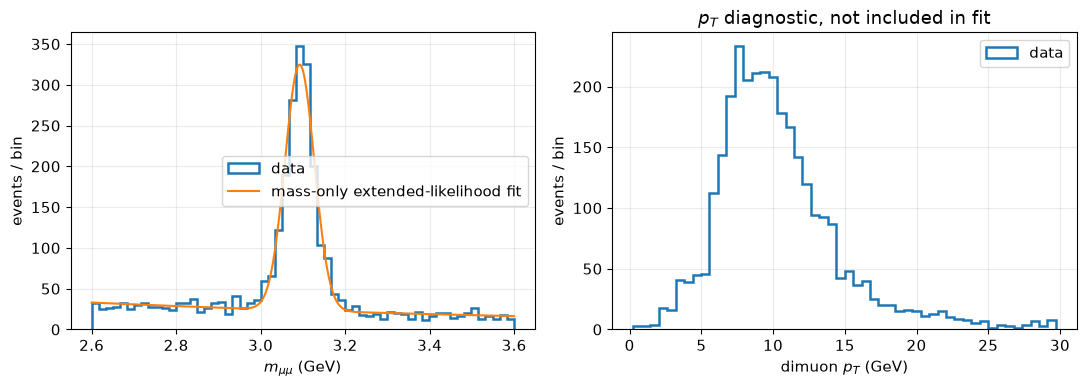

In [7]:
def mass_projection_density(mass_values, parameters):
    mass_frame = pd.DataFrame({"dimuon_mass_GeV": mass_values})
    signal_mass = truncated_gaussian_pdf(
        mass_frame["dimuon_mass_GeV"],
        parameters["mass_mean_GeV"],
        parameters["mass_sigma_GeV"],
        *MASS_RANGE,
    )
    background_mass = truncated_exponential_pdf(
        mass_frame["dimuon_mass_GeV"],
        parameters["background_mass_slope"],
        *MASS_RANGE,
    )
    return parameters["signal_yield"] * signal_mass + parameters["background_yield"] * background_mass


mass_grid = pd.DataFrame({"dimuon_mass_GeV": np.linspace(*MASS_RANGE, 400)})
mass_grid["fit_events_per_GeV"] = mass_projection_density(mass_grid["dimuon_mass_GeV"], full_fit_parameters)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

mass_counts, mass_edges, _ = axes[0].hist(analysis_data["dimuon_mass_GeV"], bins=60, histtype="step", lw=1.8, label="data")
mass_bin_width = mass_edges[1] - mass_edges[0]
axes[0].plot(mass_grid["dimuon_mass_GeV"], mass_grid["fit_events_per_GeV"] * mass_bin_width, label="mass-only extended-likelihood fit")
axes[0].set_xlabel(r"$m_{\mu\mu}$ (GeV)")
axes[0].set_ylabel("events / bin")
axes[0].legend()

axes[1].hist(analysis_data["dimuon_pt_GeV"], bins=50, histtype="step", lw=1.8, label="data")
axes[1].set_xlabel(r"dimuon $p_T$ (GeV)")
axes[1].set_ylabel("events / bin")
axes[1].set_title(r"$p_T$ diagnostic, not included in fit")
axes[1].legend()
fig.tight_layout()


### Discussion question 2

The fitted yields satisfy $N_s+N_b\approx N_\mathrm{observed}$. Is that a coincidence, a constraint we imposed by hand, or a consequence of the extended likelihood?

# Part 4: Likelihood-ratio model comparison

To test whether the data prefer a signal component in the mass spectrum, compare the full model to a background-only model. The likelihood-ratio statistic is

$$
q = -2\ln\frac{L_\mathrm{background}}{L_\mathrm{full}}
= 2\left[(-\ln L)_\mathrm{background} - (-\ln L)_\mathrm{full}\right].
$$

For regular nested models, Wilks' theorem says $q$ is approximately distributed as $\chi^2_{\Delta k}$. In this case, the signal yield is bounded below by zero, and the signal peak position and width are meaningful only when a signal component exists. Therefore the usual $\chi^2_{\Delta k}$ calibration is not exact. Still, $q$ is a useful diagnostic for how strongly the additional signal component improves the likelihood.


In [8]:
def unpack_background_parameters(transformed_parameters):
    log_background_yield, log_mass_slope = transformed_parameters
    return pd.Series(
        {
            "background_yield": np.exp(log_background_yield),
            "background_mass_slope": np.exp(log_mass_slope),
        }
    )


def background_only_intensity(data, transformed_parameters):
    parameters = unpack_background_parameters(transformed_parameters)
    mass_density = truncated_exponential_pdf(data["dimuon_mass_GeV"], parameters["background_mass_slope"], *MASS_RANGE)
    return parameters["background_yield"] * mass_density


def negative_log_likelihood_background(transformed_parameters, data=analysis_data):
    parameters = unpack_background_parameters(transformed_parameters)
    event_intensity = background_only_intensity(data, transformed_parameters)
    if np.any(event_intensity <= 0.0) or np.any(~np.isfinite(event_intensity)):
        return 1.0e30
    return parameters["background_yield"] - np.sum(np.log(event_intensity))

background_initial_parameters = np.array([np.log(len(analysis_data)), np.log(0.5)])
background_bounds = [(np.log(1.0), np.log(10000.0)), (np.log(0.001), np.log(20.0))]

background_fit_result = minimize(
    negative_log_likelihood_background,
    x0=background_initial_parameters,
    method="L-BFGS-B",
    bounds=background_bounds,
    options={"maxiter": 20000, "ftol": 1.0e-9},
)

background_fit_parameters = unpack_background_parameters(background_fit_result.x)
print("background fit success:", background_fit_result.success)
background_fit_parameters.to_frame("estimate")


background fit success: True


,estimate
background_yield,3000.000184
background_mass_slope,0.386456


### In-class coding activity 2: likelihood-ratio test, 12 minutes

Complete the likelihood-ratio comparison between the background-only and signal-plus-background models.

In [9]:
# TODO: Compute q = 2 * (NLL_background - NLL_full).
likelihood_ratio_statistic = ...

# TODO: Count the extra free parameters in the full model compared with the background-only model.
delta_parameters = ...

# TODO: Use chi2.sf(q, delta_parameters) as the approximate Wilks-theorem p-value.
approximate_p_value = ...

likelihood_ratio_table = pd.DataFrame([
    {
        "comparison": "signal + background vs background only",
        "q_delta_minus_2_log_L": likelihood_ratio_statistic,
        "delta_parameters": delta_parameters,
        "approximate_p_value": approximate_p_value,
        "caveat": "signal yield is bounded at zero; Wilks approximation is not exact",
    }
])
likelihood_ratio_table

,comparison,q_delta_minus_2_log_L,delta_parameters,approximate_p_value,caveat
0,signal + background vs background only,Ellipsis,Ellipsis,Ellipsis,signal yield is bounded at zero; Wilks approxi...


In [10]:
provided_lrt_statistic = 2.0 * (background_fit_result.fun - full_fit_result.fun)
provided_lrt_table = pd.DataFrame([
    {
        "model": "background only",
        "negative_log_likelihood": background_fit_result.fun,
        "n_parameters": 2,
    },
    {
        "model": "signal + background",
        "negative_log_likelihood": full_fit_result.fun,
        "n_parameters": 5,
    },
])
provided_lrt_table["q_vs_background"] = [np.nan, provided_lrt_statistic]
provided_lrt_table

,model,negative_log_likelihood,n_parameters,q_vs_background
0,background only,-21037.702088,2,NaN
1,signal + background,-22746.075143,5,3416.74611


# Part 5: Profile likelihood uncertainty

For one parameter of interest, a useful likelihood-based uncertainty estimate is the **profile likelihood**. Let the parameter of interest be the signal yield, which we call $\mu$, and collect all other fitted parameters into a nuisance-parameter vector $\eta$:

$$
\theta = (\mu, \eta).
$$

At each fixed value of $\mu$, we refit the nuisance parameters. This gives the best possible description of the data if the signal yield were forced to have that value:

$$
\hat{\hat{\eta}}_\mu = \arg\max_\eta L(\mu,\eta).
$$

The profile-likelihood statistic is

$$
q(\mu)= -2\ln\frac{L(\mu,\hat{\hat{\eta}}_\mu)}{L(\hat{\mu},\hat{\eta})}
= 2\left[ -\ln L(\mu,\hat{\hat{\eta}}_\mu) + \ln L(\hat{\mu},\hat{\eta}) \right].
$$

This is how correlations with nuisance parameters enter the uncertainty estimate. If the signal yield is changed, the background yield, mass resolution, peak position, and background slope are allowed to move to their best values at that fixed signal yield. The curve $q(\mu)$ therefore includes the ability of nuisance parameters to compensate for a changed signal yield.

In frequentist language, the nuisance parameters are **profiled over**. This is sometimes described informally as accounting for or eliminating nuisance parameters, but it is not the same as Bayesian marginalization, which would integrate over nuisance parameters with a prior.

For one parameter of interest, the approximate 68% confidence interval is found where

$$
\Delta q = q(\mu)-q(\hat{\mu}) = 1.
$$

In [11]:
def minimize_nuisance_parameters_for_signal_yield(fixed_signal_yield, starting_nuisance_parameters):
    """Refit all non-signal-yield parameters at one fixed signal yield."""
    log_fixed_signal_yield = np.log(fixed_signal_yield)
    nuisance_bounds = full_parameter_bounds[1:]

    def profile_objective(nuisance_parameters):
        transformed_parameters = np.concatenate([[log_fixed_signal_yield], nuisance_parameters])
        return negative_log_likelihood_full(transformed_parameters, analysis_data)

    return minimize(
        profile_objective,
        x0=starting_nuisance_parameters,
        method="L-BFGS-B",
        bounds=nuisance_bounds,
        options={"maxiter": 20000, "ftol": 1.0e-9},
    )


def crossing_points(x_values, y_values, level=1.0):
    """Find linear-interpolated x positions where y crosses a chosen level."""
    crossings = []
    for left_index in range(len(x_values) - 1):
        x1, x2 = x_values[left_index], x_values[left_index + 1]
        y1, y2 = y_values[left_index], y_values[left_index + 1]
        if (y1 - level) * (y2 - level) <= 0.0 and y1 != y2:
            crossings.append(x1 + (level - y1) * (x2 - x1) / (y2 - y1))
    return np.array(crossings)


best_signal_yield = full_fit_parameters["signal_yield"]
profile_signal_yield_grid = np.unique(
    np.concatenate(
        [
            np.linspace(0.65 * best_signal_yield, 1.35 * best_signal_yield, 45),
            [best_signal_yield],
        ]
    )
)

profile_rows = []
current_nuisance_start = full_fit_result.x[1:]

for fixed_signal_yield in profile_signal_yield_grid:
    profile_fit = minimize_nuisance_parameters_for_signal_yield(
        fixed_signal_yield,
        current_nuisance_start,
    )
    if profile_fit.success:
        current_nuisance_start = profile_fit.x

    profile_parameters = unpack_full_parameters(
        np.concatenate([[np.log(fixed_signal_yield)], profile_fit.x])
    )
    profile_rows.append(
        {
            "signal_yield": fixed_signal_yield,
            "profile_nll": profile_fit.fun,
            "profile_q": 2.0 * (profile_fit.fun - full_fit_result.fun),
            "fit_success": profile_fit.success,
            "background_yield": profile_parameters["background_yield"],
            "mass_mean_GeV": profile_parameters["mass_mean_GeV"],
            "mass_sigma_GeV": profile_parameters["mass_sigma_GeV"],
            "background_mass_slope": profile_parameters["background_mass_slope"],
        }
    )

profile_signal_yield = pd.DataFrame(profile_rows)
profile_crossings = crossing_points(
    profile_signal_yield["signal_yield"].to_numpy(),
    profile_signal_yield["profile_q"].to_numpy(),
    level=1.0,
)
profile_lower = profile_crossings[profile_crossings < best_signal_yield].max()
profile_upper = profile_crossings[profile_crossings > best_signal_yield].min()

profile_uncertainty_summary = pd.DataFrame(
    [
        {
            "parameter": "signal_yield",
            "estimate": best_signal_yield,
            "profile_lower_68": profile_lower,
            "profile_upper_68": profile_upper,
            "minus_uncertainty": best_signal_yield - profile_lower,
            "plus_uncertainty": profile_upper - best_signal_yield,
        }
    ]
)
profile_uncertainty_summary

,parameter,estimate,profile_lower_68,profile_upper_68,minus_uncertainty,plus_uncertainty
0,signal_yield,1577.496691,1533.21736,1621.456465,44.279331,43.959774


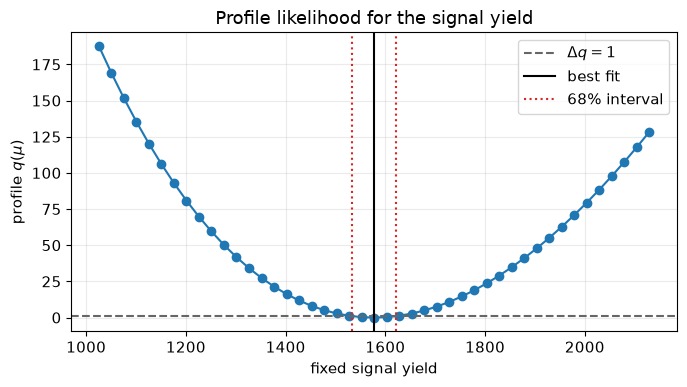

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(profile_signal_yield["signal_yield"], profile_signal_yield["profile_q"], "o-")
ax.axhline(1.0, color="0.4", ls="--", label=r"$\Delta q=1$")
ax.axvline(best_signal_yield, color="black", lw=1.5, label="best fit")
ax.axvline(profile_lower, color="C3", ls=":", label="68% interval")
ax.axvline(profile_upper, color="C3", ls=":")
ax.set_xlabel("fixed signal yield")
ax.set_ylabel(r"profile $q(\mu)$")
ax.set_title("Profile likelihood for the signal yield")
ax.legend()
fig.tight_layout()

# Part 6: Parametric bootstrap

A parametric bootstrap repeats the experiment under the fitted mass model:

1. Draw a total number of events from $\mathrm{Poisson}(N_s+N_b)$.
2. Assign each event to signal or background with probabilities proportional to $N_s$ and $N_b$.
3. Draw mass values from the fitted signal or background densities.
4. Refit each fake dataset.

The spread of refitted parameters estimates the uncertainty implied by the full simulation of the fitted measurement model.


In [13]:
def sample_truncated_exponential(size, slope, lower, upper, rng):
    width = upper - lower
    uniform = rng.uniform(size=size)
    if abs(slope) < 1.0e-10:
        return lower + width * uniform
    return lower - np.log(1.0 - uniform * (1.0 - np.exp(-slope * width))) / slope


def sample_truncated_gaussian(size, mean, sigma, lower, upper, rng):
    samples = []
    while len(samples) < size:
        proposal = rng.normal(mean, sigma, size=max(100, 2 * (size - len(samples))))
        accepted = proposal[(proposal >= lower) & (proposal <= upper)]
        samples.extend(accepted.tolist())
    return np.array(samples[:size])


def simulate_from_full_model(parameters, rng):
    expected_events = parameters["signal_yield"] + parameters["background_yield"]
    n_events = rng.poisson(expected_events)
    signal_probability = parameters["signal_yield"] / expected_events
    is_signal = rng.uniform(size=n_events) < signal_probability

    simulated_mass = np.empty(n_events)

    n_signal = int(is_signal.sum())
    n_background = n_events - n_signal

    simulated_mass[is_signal] = sample_truncated_gaussian(
        n_signal,
        parameters["mass_mean_GeV"],
        parameters["mass_sigma_GeV"],
        *MASS_RANGE,
        rng,
    )

    simulated_mass[~is_signal] = sample_truncated_exponential(
        n_background,
        parameters["background_mass_slope"],
        *MASS_RANGE,
        rng,
    )

    return pd.DataFrame({"dimuon_mass_GeV": simulated_mass})


def fit_full_model(data, starting_point=full_fit_result.x):
    return minimize(
        negative_log_likelihood_full,
        x0=starting_point,
        args=(data,),
        method="L-BFGS-B",
        bounds=full_parameter_bounds,
        options={"maxiter": 20000, "ftol": 1.0e-9},
    )

bootstrap_rows = []
number_of_bootstrap_samples = 80

for sample_index in range(number_of_bootstrap_samples):
    bootstrap_data = simulate_from_full_model(full_fit_parameters, rng)
    bootstrap_fit = fit_full_model(bootstrap_data)
    if not bootstrap_fit.success:
        continue
    bootstrap_parameters = unpack_full_parameters(bootstrap_fit.x)
    bootstrap_rows.append({"sample": sample_index, **bootstrap_parameters.to_dict()})

bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_results.head()


,sample,signal_yield,background_yield,mass_mean_GeV,mass_sigma_GeV,background_mass_slope
0,0,1564.991852,1411.879466,3.092076,0.034495,0.865322
1,1,1648.806857,1388.206930,3.091912,0.035207,0.701565
2,2,1596.246452,1422.755459,3.090082,0.034881,0.770906
3,3,1575.210710,1460.734005,3.090080,0.033964,0.550481
4,4,1582.696621,1358.304041,3.090612,0.034241,0.759231


### In-class coding activity 3: summarize bootstrap uncertainty, 10 minutes

Complete the bootstrap summary for the signal yield, mass mean, and mass width.

In [14]:
# TODO: Choose the parameters to summarize from bootstrap_results.
bootstrap_columns_to_summarize = ...

bootstrap_summary_rows = []
for column in bootstrap_columns_to_summarize:
    values = bootstrap_results[column]
    bootstrap_summary_rows.append(
        {
            "parameter": column,
            "bootstrap_mean": ...,  # TODO: mean of bootstrap values.
            "bootstrap_std": ...,   # TODO: standard deviation of bootstrap values.
            "p16": ...,             # TODO: 16th percentile.
            "p84": ...,             # TODO: 84th percentile.
        }
    )

bootstrap_summary = pd.DataFrame(bootstrap_summary_rows)
bootstrap_summary

TypeError: 'ellipsis' object is not iterable

In [ ]:
bootstrap_parameters_to_summarize = ["signal_yield", "mass_mean_GeV", "mass_sigma_GeV"]

provided_bootstrap_summary_rows = []
for parameter_name in bootstrap_parameters_to_summarize:
    bootstrap_values = bootstrap_results[parameter_name]
    provided_bootstrap_summary_rows.append(
        {
            "parameter": parameter_name,
            "bootstrap_mean": bootstrap_values.mean(),
            "bootstrap_std": bootstrap_values.std(ddof=1),
            "p16": np.percentile(bootstrap_values, 16),
            "p84": np.percentile(bootstrap_values, 84),
        }
    )

provided_bootstrap_summary = pd.DataFrame(provided_bootstrap_summary_rows)
provided_bootstrap_summary


,parameter,bootstrap_mean,bootstrap_std,p16,p84
0,signal_yield,1583.949934,39.964706,1542.646016,1623.681250
1,mass_mean_GeV,3.092179,0.001065,3.091231,3.093425
2,mass_sigma_GeV,0.034596,0.000999,0.033844,0.035281


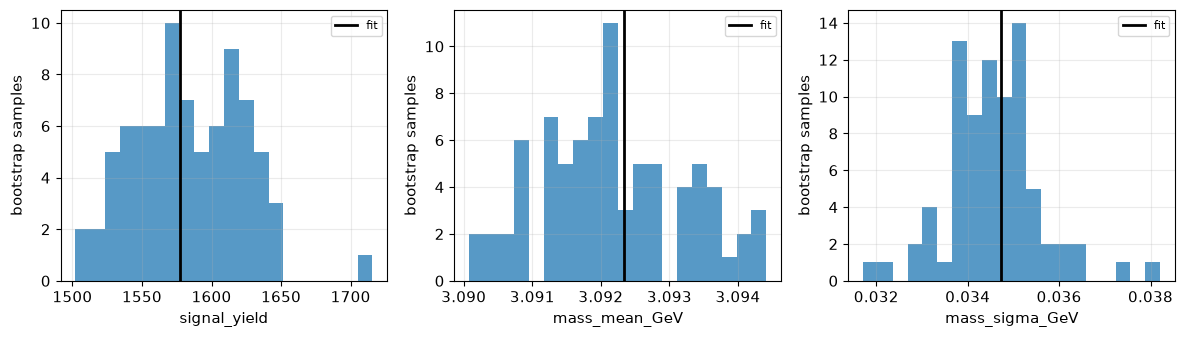

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for axis, column in zip(axes, ["signal_yield", "mass_mean_GeV", "mass_sigma_GeV"]):
    axis.hist(bootstrap_results[column], bins=20, alpha=0.75)
    axis.axvline(full_fit_parameters[column], color="black", lw=2, label="fit")
    axis.set_xlabel(column)
    axis.set_ylabel("bootstrap samples")
    axis.legend(fontsize=8)
fig.tight_layout()

The histograms above show the one-parameter bootstrap distributions. A **pair plot** shows a different piece of information: whether two fitted parameters move together across repeated fake experiments. Tilted or elongated point clouds indicate correlation. This is especially useful for nuisance parameters, because a change in one nuisance parameter can partially compensate for a change in another parameter while giving a similar likelihood value.

The number printed in each upper-triangle panel is the Pearson correlation coefficient,

$$
\rho_{ij}=\frac{\mathrm{cov}(\theta_i,\theta_j)}{\sigma_i\sigma_j}.
$$

This is closely related to the covariance matrices used in previous least-squares fits. A covariance matrix stores the absolute joint spread of parameters in their physical units; the correlation matrix rescales each covariance by the two parameter uncertainties, so every entry is dimensionless and lies between $-1$ and $+1$. Here the covariance and correlation are estimated empirically from the bootstrap ensemble rather than from the local curvature of a fitted objective function.

In [ ]:
pair_plot_columns = [
    "signal_yield",
    "background_yield",
    "mass_mean_GeV",
    "mass_sigma_GeV",
    "background_mass_slope",
]

pair_plot_data = bootstrap_results[pair_plot_columns].copy()
pair_plot_correlation = pair_plot_data.corr()

axes = scatter_matrix(
    pair_plot_data,
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.65,
    s=18,
)

for row_index, y_column in enumerate(pair_plot_columns):
    for column_index, x_column in enumerate(pair_plot_columns):
        axis = axes[row_index, column_index]
        if row_index == column_index:
            axis.axvline(full_fit_parameters[x_column], color="black", lw=1.5)
        else:
            axis.axvline(full_fit_parameters[x_column], color="black", lw=0.8, alpha=0.6)
            axis.axhline(full_fit_parameters[y_column], color="black", lw=0.8, alpha=0.6)

        # Show the numerical correlation on one half of the pair plot.
        if column_index > row_index:
            rho = pair_plot_correlation.loc[y_column, x_column]
            axis.text(
                0.05,
                0.88,
                rf"$\rho={rho:.2f}$",
                transform=axis.transAxes,
                fontsize=10,
                bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.85},
            )

fig = axes[0, 0].figure
fig.suptitle("Bootstrap pair plot for fitted mass-model parameters", y=1.02)
fig.tight_layout()

In [ ]:
pair_plot_correlation.round(2)

# Part 7: Jackknife influence diagnostics

A full leave-one-event-out jackknife would require 3000 refits, which is too slow for class. Instead, use a **leave-one-mass-bin-out** diagnostic: remove one mass slice at a time, refit, and see which regions most affect the signal yield or peak position.

In [ ]:
mass_bin_edges = np.linspace(*MASS_RANGE, 21)
jackknife_rows = []

for bin_index in range(len(mass_bin_edges) - 1):
    bin_low = mass_bin_edges[bin_index]
    bin_high = mass_bin_edges[bin_index + 1]
    keep_mask = ~analysis_data["dimuon_mass_GeV"].between(bin_low, bin_high, inclusive="left")
    jackknife_data = analysis_data.loc[keep_mask].reset_index(drop=True)
    jackknife_fit = fit_full_model(jackknife_data)
    if not jackknife_fit.success:
        continue
    jackknife_parameters = unpack_full_parameters(jackknife_fit.x)
    jackknife_rows.append(
        {
            "omitted_bin_low": bin_low,
            "omitted_bin_high": bin_high,
            "omitted_bin_center": 0.5 * (bin_low + bin_high),
            "n_omitted": int((~keep_mask).sum()),
            **jackknife_parameters.to_dict(),
        }
    )

jackknife_results = pd.DataFrame(jackknife_rows)
jackknife_results["signal_yield_shift"] = jackknife_results["signal_yield"] - full_fit_parameters["signal_yield"]
jackknife_results["mass_mean_shift"] = jackknife_results["mass_mean_GeV"] - full_fit_parameters["mass_mean_GeV"]
jackknife_results.head()

In [ ]:
most_influential_bins = jackknife_results.reindex(
    jackknife_results["signal_yield_shift"].abs().sort_values(ascending=False).index
)
most_influential_bins[["omitted_bin_low", "omitted_bin_high", "n_omitted", "signal_yield_shift", "mass_mean_shift"]].head()

In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
axes[0].axhline(0.0, color="0.5", lw=1)
axes[0].plot(jackknife_results["omitted_bin_center"], jackknife_results["signal_yield_shift"], "o-")
axes[0].set_ylabel("signal yield shift")

axes[1].axhline(0.0, color="0.5", lw=1)
axes[1].plot(jackknife_results["omitted_bin_center"], 1000.0 * jackknife_results["mass_mean_shift"], "o-")
axes[1].set_xlabel(r"omitted mass-bin center (GeV)")
axes[1].set_ylabel("mass mean shift (MeV)")
fig.tight_layout()

### Discussion question 3

If omitting the mass bin at the peak shifts the signal yield strongly, is that a problem with the fit, expected behavior, or both? What would be more concerning: a large shift near the peak or a large shift far away in the sideband?

# Part 8: Comparing uncertainty estimates

The table below compares uncertainty estimates from three ideas:

- profile likelihood: fix one parameter of interest and refit the nuisance parameters,
- bootstrap: repeated fake experiments generated from the fitted mass intensity,
- jackknife: sensitivity to removing mass regions.

The profile-likelihood entry is shown for the signal yield, because that is the parameter profiled explicitly above. Bootstrap and jackknife estimates can be computed for several parameters. These methods do not answer identical questions, so disagreement is a diagnostic, not just an inconvenience.

In [ ]:
comparison_parameters = ["signal_yield", "mass_mean_GeV", "mass_sigma_GeV"]
uncertainty_comparison = full_fit_parameters.loc[comparison_parameters].rename("estimate").reset_index()
uncertainty_comparison = uncertainty_comparison.rename(columns={"index": "parameter"})

profile_columns = ["parameter", "minus_uncertainty", "plus_uncertainty"]
uncertainty_comparison = uncertainty_comparison.merge(
    profile_uncertainty_summary[profile_columns],
    on="parameter",
    how="left",
)

bootstrap_std = bootstrap_results[comparison_parameters].std().rename("bootstrap_std").reset_index().rename(columns={"index": "parameter"})
jackknife_max_shift = (
    jackknife_results[["signal_yield_shift", "mass_mean_shift"]]
    .abs()
    .max()
    .rename(index={"signal_yield_shift": "signal_yield", "mass_mean_shift": "mass_mean_GeV"})
    .rename("max_leave_bin_out_shift")
    .reset_index()
    .rename(columns={"index": "parameter"})
)

uncertainty_comparison = uncertainty_comparison.merge(bootstrap_std, on="parameter", how="left")
uncertainty_comparison = uncertainty_comparison.merge(jackknife_max_shift, on="parameter", how="left")
uncertainty_comparison

# Part 9: Takeaways

- In an event-wise Poisson model, $I(m;\theta)$ is a mass intensity, $\theta$ is the parameter vector to be inferred, and $N_\mathrm{expected}=\int I(m;\theta)\,dm$ is the expected number of events in the selected mass range.
- The extended likelihood uses both the total event count and the locations of the events in mass.
- A likelihood-ratio statistic compares nested intensity models, but boundary cases and non-identifiable signal-shape parameters require care.
- A profile likelihood estimates uncertainty on one parameter while allowing correlated nuisance parameters to re-optimize at each fixed value.
- Bootstrap resampling estimates the spread from repeated experiments under an assumed model.
- Jackknife diagnostics show which data regions have high influence on a fitted result.
- Profile likelihood, bootstrap, and jackknife uncertainties are complementary; they should be compared, not blindly averaged.
- Diagnostic distributions, such as dimuon $p_T$, can reveal when a tempting model component should not be included without a better physical or empirical description.

# References and Further Reading

- D. W. Hogg, J. Bovy, and D. Lang, **Data analysis recipes: Fitting a model to data**, arXiv:1008.4686: https://arxiv.org/abs/1008.4686. See also the course [Unit 2 resources](../resources/unit-2-data-analysis.md).
- T. McCauley, **Dimuon event information derived from the Run2010B public Mu dataset**, CERN Open Data Portal (2014), DOI: [10.7483/OPENDATA.CMS.CB8H.MFFA](https://doi.org/10.7483/OPENDATA.CMS.CB8H.MFFA).
- ROOT project, **RDataFrame CSV data-source tutorial**, using the CMS Run2010B dimuon CSV: https://root.cern/doc/master/df014__CSVDataSource_8C.html
- R. Barlow, **Extended maximum likelihood**, *Nucl. Instrum. Meth. A* 297, 496-506 (1990), DOI: [10.1016/0168-9002(90)91334-8](https://doi.org/10.1016/0168-9002(90)91334-8).
- Particle Data Group, **Statistics review**, in *Review of Particle Physics*: https://pdg.lbl.gov/
- B. Efron and R. Tibshirani, **Bootstrap Methods for Standard Errors, Confidence Intervals, and Other Measures of Statistical Accuracy**, *Statistical Science* 1, 54-75 (1986), DOI: [10.1214/ss/1177013815](https://doi.org/10.1214/ss/1177013815).
- B. Efron, **The Jackknife, the Bootstrap and Other Resampling Plans**, SIAM (1982), DOI: [10.1137/1.9781611970319](https://doi.org/10.1137/1.9781611970319).